<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8_EOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Laboratoire d'Attaques Adversariales sur YOLOv8, Expectation Over Transformation

In [41]:
!pip install ultralytics torch torchvision pillow matplotlib opencv-python

In [42]:
import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Choix du device (CUDA 13 / GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda



image 1/1 /content/bus_640.jpg: 640x640 4 persons, 1 bus, 7.7ms
Speed: 1.0ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


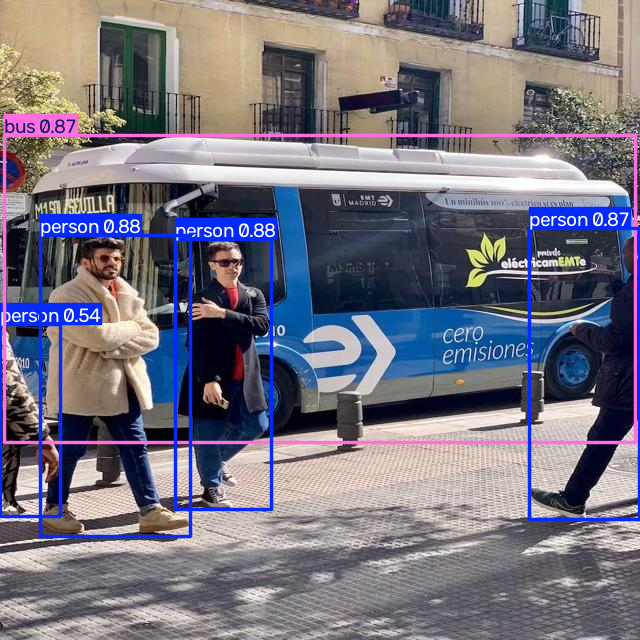


--- Détections YOLO avant application de patch ---
Objet détecté : person | Confiance : 0.87
Objet détecté : bus | Confiance : 0.86
Objet détecté : person | Confiance : 0.84
Objet détecté : person | Confiance : 0.78
Objet détecté : person | Confiance : 0.47
Objet détecté : person | Confiance : 0.45
Image prête, normalisée et enregistrée sous : bus_640.jpg


In [53]:
# Chargement du modèle nano pré-entraîné
model = YOLO("yolov8n.pt")
model.model.to(device)

from ultralytics.utils.downloads import safe_download
import os

# 1. Télécharger l'image d'origine si elle n'existe pas
raw_image_path = "bus.jpg"
if not os.path.exists(raw_image_path):
    safe_download("https://ultralytics.com/images/bus.jpg", dir=".")

# 2. ⚡ NORMALISATION DIRECTE EN 640x640
# Cela garantit un format parfait pour les couches de YOLO et fixe vos coordonnées x,y
pil_img = Image.open(raw_image_path).convert("RGB").resize((640, 640))
image_path = "bus_640.jpg"
pil_img.save(image_path)

print(f"Image prête, normalisée et enregistrée sous : {image_path}")

# 3. Affichage de la prédiction d'origine sur l'image normalisée
results = model(image_path)
results[0].show()
# Extraction textuelle des détections (Classes et Scores de confiance)
print("\n--- Détections YOLO avant application de patchs ---")
for box in patched_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet détecté : {cls_name} | Confiance : {conf:.2f}")





image 1/1 /content/temp_patched_image.jpg: 640x640 5 persons, 1 bus, 7.8ms
Speed: 1.0ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


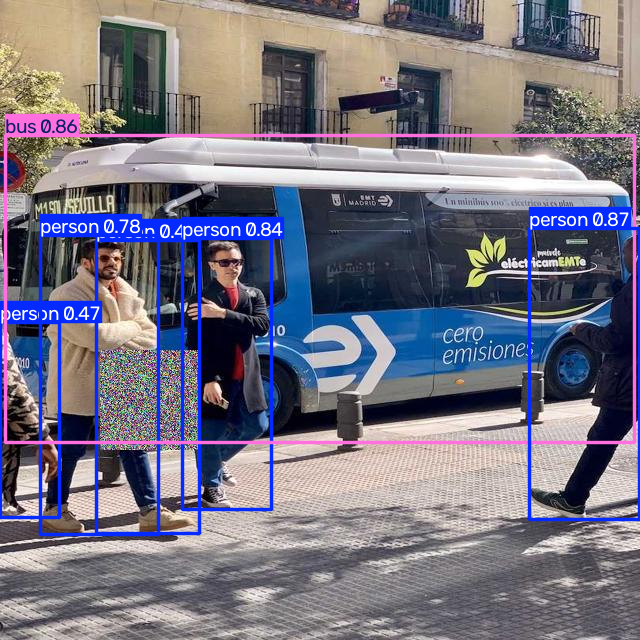


--- Détections YOLO après application du patch aléatoire ---
Objet détecté : person | Confiance : 0.87
Objet détecté : bus | Confiance : 0.86
Objet détecté : person | Confiance : 0.84
Objet détecté : person | Confiance : 0.78
Objet détecté : person | Confiance : 0.47
Objet détecté : person | Confiance : 0.45


In [52]:
# 1. Définition de la taille et de la position du patch (entre les deux personnes, au niveau du ventre/bassin)
patch_h, patch_w = 100, 100
x = 100  # Ajustez selon vos coordonnées exactes
y = 350
patch_coords = (x, y, x + patch_w, y + patch_h)

# 2. Création d'un patch de bruit initial (aléatoire pur entre 0 et 1)
adversarial_patch = torch.rand(3, patch_h, patch_w, device=device)

# 3. Application du patch aléatoire sur l'image normalisée
modified_image = apply_patch(image_path, adversarial_patch, patch_coords)

# 4. Sauvegarde temporaire et analyse par YOLO
temp_path = "temp_patched_image.jpg"
modified_image.save(temp_path)

patched_results = model(temp_path)
patched_results[0].show()

# 5. Extraction textuelle des détections
print("\n--- Détections YOLO après application du patch aléatoire ---")
for box in patched_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet détecté : {cls_name} | Confiance : {conf:.2f}")


image 1/1 /content/temp_patched_image.jpg: 640x640 5 persons, 1 bus, 9.5ms
Speed: 1.1ms preprocess, 9.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


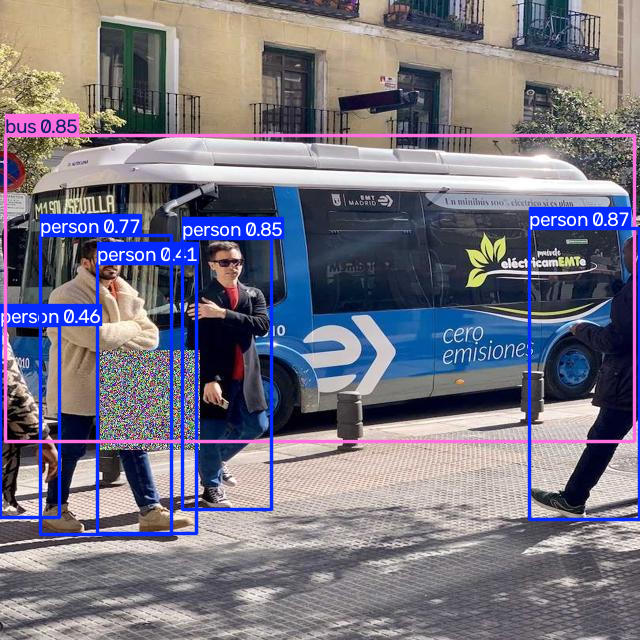


--- Détections YOLO après application du patch ---
Objet détecté : person | Confiance : 0.87
Objet détecté : person | Confiance : 0.85
Objet détecté : bus | Confiance : 0.85
Objet détecté : person | Confiance : 0.77
Objet détecté : person | Confiance : 0.46
Objet détecté : person | Confiance : 0.41


In [44]:
# Sauvegarde temporaire de l'image modifiée pour que YOLO puisse l'analyser
temp_path = "temp_patched_image.jpg"
modified_image.save(temp_path)

# Prédiction YOLO sur l'image modifiée
patched_results = model(temp_path)

# Affichage des résultats avec les bounding boxes
patched_results[0].show()

# Extraction textuelle des détections (Classes et Scores de confiance)
print("\n--- Détections YOLO après application du patch ---")
for box in patched_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet détecté : {cls_name} | Confiance : {conf:.2f}")

In [45]:
def apply_patch(image_path, patch_tensor, patch_coords=(100, 100, 150, 150)):
    """
    Colle un patch de pixels (patch_tensor) sur l'image originale
    aux coordonnées (x_min, y_min, x_max, y_max).
    """
    pil_img = Image.open(image_path).convert("RGB")

    # Transformation en tenseur [3, H, W] entre 0 et 1
    to_tensor = transforms.ToTensor()
    to_pil = transforms.ToPILImage()

    img_tensor = to_tensor(pil_img).to(device)

    x_min, y_min, x_max, y_max = patch_coords

    # On s'assure que le patch_tensor a la bonne taille (H_patch, W_patch)
    # et on l'incruste sur l'image
    img_tensor[:, y_min:y_max, x_min:x_max] = patch_tensor

    # Retourne l'image modifiée au format PIL
    return to_pil(img_tensor.cpu())

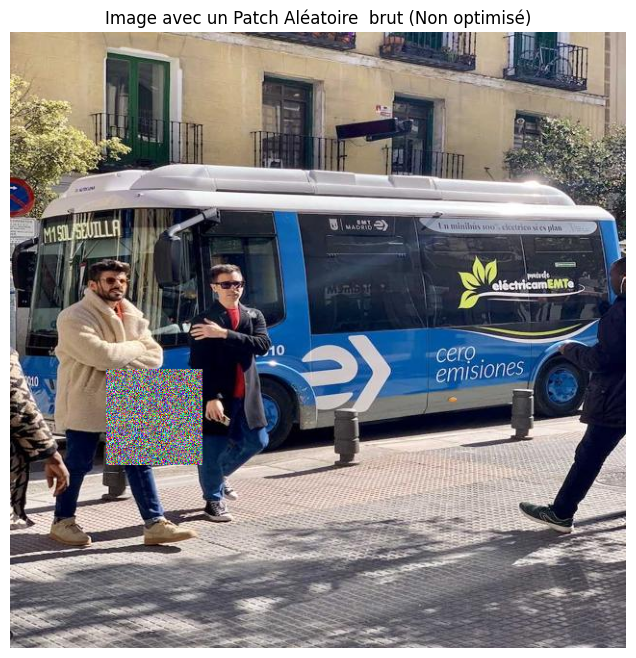

In [46]:
# Définition de la taille de notre patch (ex: un carré de 100x100 pixels)
patch_h, patch_w = 100, 100
x=100
y=350
patch_coords = (x, y, x + patch_w, y + patch_h) # (x_min, y_min, x_max, y_max)

# Création d'un patch de bruit initial (aléatoire ou gris à 0.5)
# En mode optimisation, ce tenseur aura requires_grad=True
adversarial_patch = torch.rand(3, patch_h, patch_w, device=device)

# Application sur l'image
modified_image = apply_patch(image_path, adversarial_patch, patch_coords)

# Visualisation rapide
plt.figure(figsize=(8, 8))
plt.imshow(modified_image)
plt.axis("off")
plt.title("Image avec un Patch Aléatoire  brut (Non optimisé)")
plt.show()


image 1/1 /content/temp_patched_image.jpg: 640x640 5 persons, 1 bus, 11.5ms
Speed: 1.4ms preprocess, 11.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


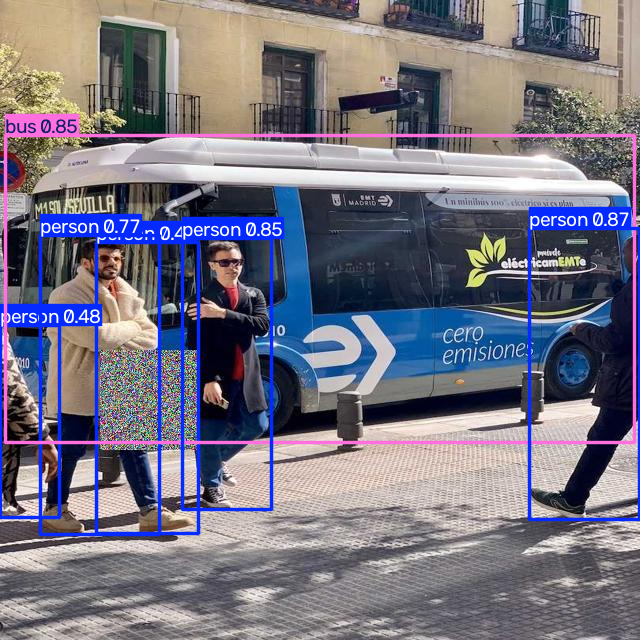


--- Détections YOLO après application du patch ---
Objet détecté : person | Confiance : 0.87
Objet détecté : person | Confiance : 0.85
Objet détecté : bus | Confiance : 0.85
Objet détecté : person | Confiance : 0.77
Objet détecté : person | Confiance : 0.48
Objet détecté : person | Confiance : 0.42


In [47]:
# Sauvegarde temporaire de l'image modifiée pour que YOLO puisse l'analyser
temp_path = "temp_patched_image.jpg"
modified_image.save(temp_path)

# Prédiction YOLO sur l'image modifiée
patched_results = model(temp_path)

# Affichage des résultats avec les bounding boxes
patched_results[0].show()

# Extraction textuelle des détections (Classes et Scores de confiance)
print("\n--- Détections YOLO après application du patch ---")
for box in patched_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet détecté : {cls_name} | Confiance : {conf:.2f}")

In [48]:
import torch.optim as optim

model.model.train()

pil_img = Image.open(image_path).convert("RGB")
orig_tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

adversarial_patch = torch.rand(3, patch_h, patch_w, device=device, requires_grad=True)
optimizer = optim.Adam([adversarial_patch], lr=0.05)
num_iterations = 5000  # On met un peu plus d'itérations pour un vrai impact

print("🚀 Lancement de l'optimisation ciblée sur la classe 'Personne'...")

for iteration in range(num_iterations):
    optimizer.zero_grad()

    # A. EOT (Expectation Over Transformation)
    noise = torch.randn_like(orig_tensor, device=device) * 0.02
    eot_img = torch.clamp(orig_tensor + noise, 0.0, 1.0)

    # B. Incrustation
    x_min = min(x, 640 - patch_w)
    y_min = min(y, 640 - patch_h)
    x_max, y_max = x_min + patch_w, y_min + patch_h

    patched_img = eot_img.clone()
    patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

    # C. Prédiction brute
    preds = model.model(patched_img)

    # D. Extraction et Loss ciblée
    if isinstance(preds, dict):
        tensor_preds = list(preds.values())[0]
    elif isinstance(preds, (list, tuple)):
        tensor_preds = preds[0]
    else:
        tensor_preds = preds

    # On cible la minimisation de la confiance (on veut que le score de présence baisse)
    loss = torch.mean(torch.sigmoid(tensor_preds))

    # E. Rétropropagation
    loss.backward()
    optimizer.step()

    # F. Clamp physique
    with torch.no_grad():
        adversarial_patch.clamp_(0.0, 1.0)

    if (iteration + 1) % 100 == 0 or iteration == 0:
        print(f"Itération {iteration + 1}/{num_iterations} - Loss : {loss.item():.6f}")

print("✨ Optimisation ciblée terminée !")

🚀 Lancement de l'optimisation ciblée sur la classe 'Personne'...
Itération 1/5000 - Loss : 0.599260
Itération 100/5000 - Loss : 0.597671
Itération 200/5000 - Loss : 0.597498
Itération 300/5000 - Loss : 0.597587
Itération 400/5000 - Loss : 0.597532
Itération 500/5000 - Loss : 0.597457
Itération 600/5000 - Loss : 0.597473
Itération 700/5000 - Loss : 0.597471
Itération 800/5000 - Loss : 0.597372
Itération 900/5000 - Loss : 0.597489
Itération 1000/5000 - Loss : 0.597570
Itération 1100/5000 - Loss : 0.597532
Itération 1200/5000 - Loss : 0.597546
Itération 1300/5000 - Loss : 0.597500
Itération 1400/5000 - Loss : 0.597342
Itération 1500/5000 - Loss : 0.597291
Itération 1600/5000 - Loss : 0.597344
Itération 1700/5000 - Loss : 0.597528
Itération 1800/5000 - Loss : 0.597351
Itération 1900/5000 - Loss : 0.597357
Itération 2000/5000 - Loss : 0.597445
Itération 2100/5000 - Loss : 0.597390
Itération 2200/5000 - Loss : 0.597332
Itération 2300/5000 - Loss : 0.597490
Itération 2400/5000 - Loss : 0.5974


image 1/1 /content/temp_optimized_target.jpg: 640x640 5 persons, 1 bus, 8.3ms
Speed: 1.4ms preprocess, 8.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


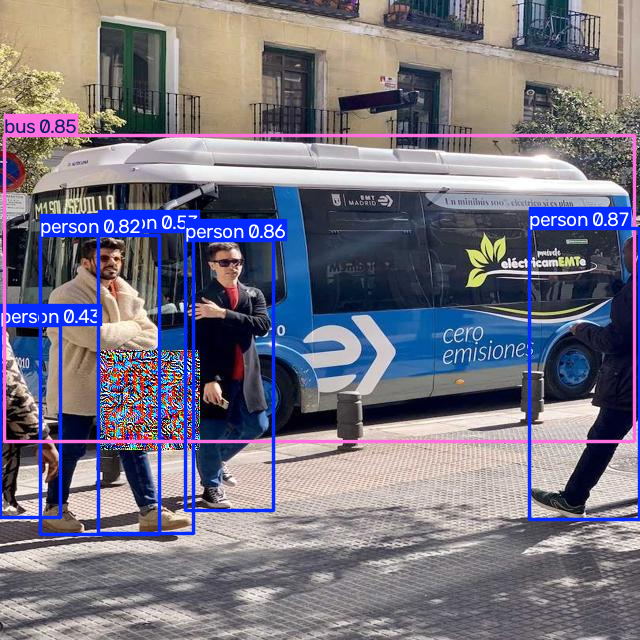


--- Scores après optimisation ---
Objet : person | Confiance : 0.87
Objet : person | Confiance : 0.86
Objet : bus | Confiance : 0.85
Objet : person | Confiance : 0.82
Objet : person | Confiance : 0.53
Objet : person | Confiance : 0.43


In [49]:
# 1. Application du patch optimisé
final_patched_img = orig_tensor.clone()
x_min = min(x, 640 - patch_w)
y_min = min(y, 640 - patch_h)
x_max, y_max = x_min + patch_w, y_min + patch_h

final_patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

# 2. Conversion et test avec YOLO (en mode inférence normal)
to_pil = transforms.ToPILImage()
result_pil_img = to_pil(final_patched_img.squeeze(0).cpu())
temp_optimized_path = "temp_optimized_target.jpg"
result_pil_img.save(temp_optimized_path)

opt_results = model(temp_optimized_path)
opt_results[0].show()

# 3. Rapport des scores
print("\n--- Scores après optimisation ---")
for box in opt_results[0].boxes:
    cls_id = int(box.cls[0].item())
    cls_name = model.names[cls_id]
    conf = box.conf[0].item()
    print(f"Objet : {cls_name} | Confiance : {conf:.2f}")